In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
#TASK 1 : DATASET UNDERSTANDING
print("TASK 1 : DATA UNDERSTANDING")
# Load Dataset
df = pd.read_csv("/content/Dataset for Data Analytics - Sheet1.csv")
print("first 5 rwows",df.head()) # Display first 5 rows
print("Dataset information",df.info())  # Dataset information
# Shape of dataset
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])
print("Columns",df.columns) # Columns
print("Data types",df.dtypes)  # Data Types
print("Description",df.describe())  # Description

# Description of Dataset
print("\nDataset contains e-commerce order details such as:")
print("- Products purchased")
print("- Quantity")
print("- Unit Price")
print("- Payment Methods")
print("- Order Status")
print("- Total Price")
print("- Referral Sources")

TASK 1 : DATA UNDERSTANDING
first 5 rwows      OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SA

In [3]:
# TASK 2 : DATA CLEANING & PREPROCESSING
print("TASK 2 : DATA CLEANING & PREPROCESSING")
#Check missing values
print("Missing Values:")
print(df.isnull().sum())
# Remove duplicates
df = df.drop_duplicates()

print("Duplicates Removed Successfully")
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Check cleaned dataset
print("CLEANED DATASET INFO ")
print(df.info())


TASK 2 : DATA CLEANING & PREPROCESSING
Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64
Duplicates Removed Successfully
CLEANED DATASET INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  120

In [4]:
# TASK 3 : EXPLORATORY DATA ANALYSIS (EDA)
print("TASK 3: EDA")
print("TOTAL SALES:",df['TotalPrice'].sum())
print("AVERAGE ORDER VALUES:",df['TotalPrice'].mean())
print("MOST SOLD PRODUCT:",print(df['Product'].value_counts().head()))
print("PAYMENT METHOD USAGE:",df['PaymentMethod'].value_counts())
print("ORDER STATUS:",print(df['OrderStatus'].value_counts()))

# Detect Outliers
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df['TotalPrice'] < (Q1 - 1.5 * IQR)) |
    (df['TotalPrice'] > (Q3 + 1.5 * IQR))
]

print("OUTLIERS IN TOTAL PRICE")
print(outliers.shape[0])

TASK 3: EDA
TOTAL SALES: 1264761.96
AVERAGE ORDER VALUES: 1053.9683
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Name: count, dtype: int64
MOST SOLD PRODUCT: None
PAYMENT METHOD USAGE: PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
ORDER STATUS: None
OUTLIERS IN TOTAL PRICE
8


DATA VISUALIZATION


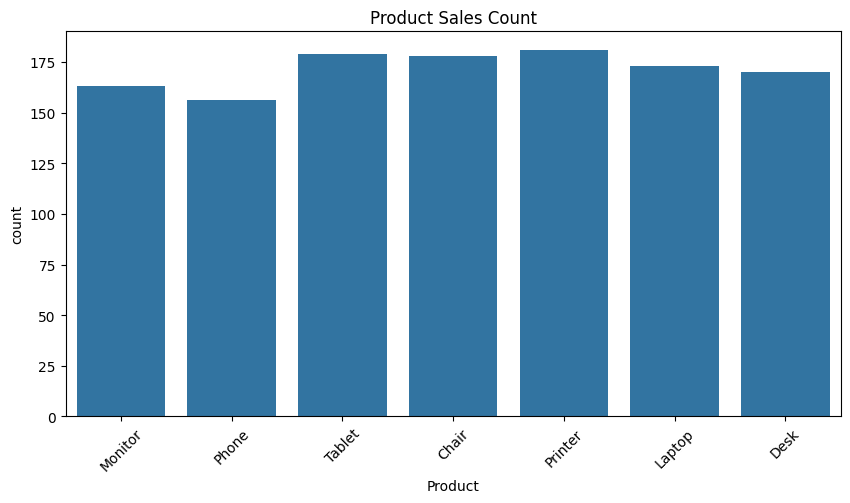

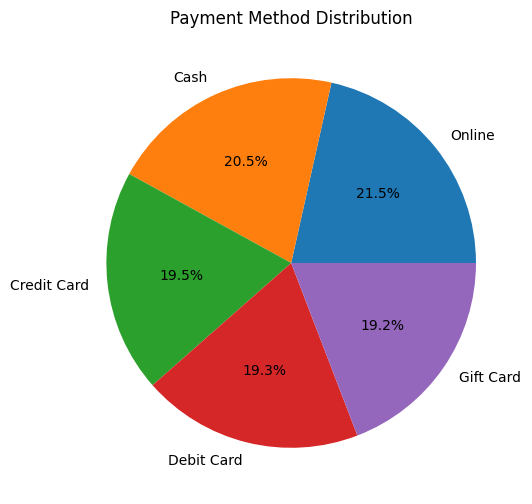

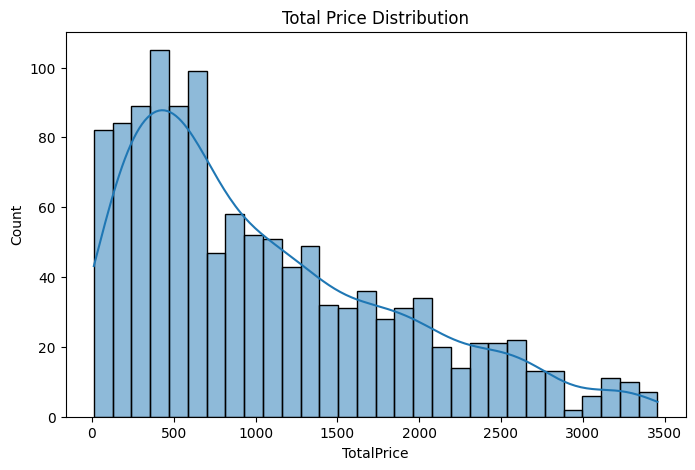

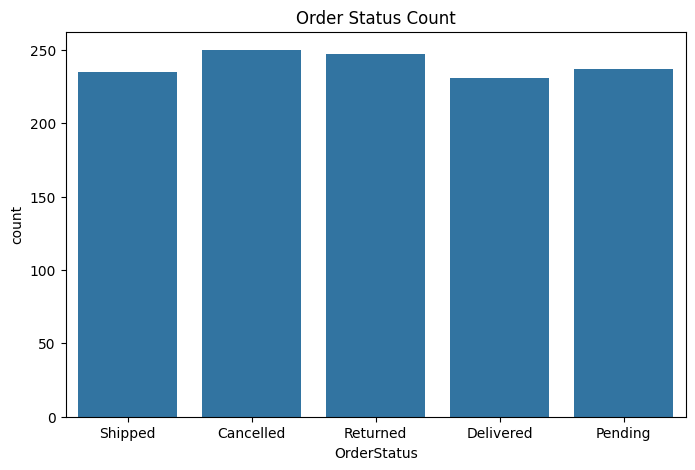

In [5]:
# TASK 4 : DATA VISUALIZATION
print("DATA VISUALIZATION")

# Product Sales Count
plt.figure(figsize=(10,5))
sns.countplot(x='Product', data=df)
plt.title("Product Sales Count")
plt.xticks(rotation=45)
plt.show()

# Payment Method Distribution
plt.figure(figsize=(6,6))
df['PaymentMethod'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

# Total Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['TotalPrice'], bins=30, kde=True)
plt.title("Total Price Distribution")
plt.show()

# Order Status Visualization
plt.figure(figsize=(8,5))
sns.countplot(x='OrderStatus', data=df)
plt.title("Order Status Count")
plt.show()



In [6]:
#TASK 5 : PREDICTIVE MODEL
print("TASK 5 : PREDICTIVE MODEL")

X = df[['Quantity', 'UnitPrice', 'ItemsInCart']]
y = df['TotalPrice']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

TASK 5 : PREDICTIVE MODEL
MODEL PERFORMANCE
Mean Absolute Error: 211.52582150138198
R2 Score: 0.8904918215121346


The model achieved
good prediction performance based on MAE and R2 Score.